# Tranformers-Based Models

# DistilBert

DistilBERT is a compressed version of BERT developed using a technique called knowledge distillation. Instead of training from scratch, DistilBERT is trained to mimic the behavior of the full BERT model, learning to reproduce its outputs while using a much smaller architecture.

Compared to BERT base, DistilBERT has 6 transformer layers instead of 12, ~66M parameters instead of ~110M.

In order to perform financial sentiment analysis we decidec to **fine-tune** DistilBert, meaning that all the the six layers of the pre-trained model are updated and trained with our data

In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import  DistilBertForSequenceClassification, DistilBertConfig, get_linear_schedule_with_warmup
from torch.optim import AdamW
import os
from sklearn.model_selection import train_test_split


c:\Text Mining\Text_Mining\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
checkpoint_dir_256 = "Bert_weights/bert_checkpoints_256token"  # We store here the weights
os.makedirs(checkpoint_dir_256, exist_ok=True)


In [3]:


file_path = "financial_news_base.jsonl" 

df = pd.read_json(file_path, lines=True)


## Data Preprocessing Order: Filter First, Then Subsample

In this notebook we use `max_length=256` tokens for tokenization, since the 96% of the documents have number of tokens smaller than that and using 256 as max length we speed up a lot the training phase.

So we deleted all the documents that have nomber of tokens higher than 256 tokens. 

Then to obtain balanced classes, we subsample 25000 observations (8333 from each class)


In [4]:
from transformers import DistilBertTokenizer 

MAX_LEN = 256

# Step 1: Filter rows with more than 256 tokens on the ORIGINAL dataset (before balancing)
tokenizer_temp = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
mask_256 = df["description"].apply(
    lambda t: len(tokenizer_temp.encode(str(t), add_special_tokens=True)) <= MAX_LEN 
)
df_filtered = df[mask_256].reset_index(drop=True)
print(f"Original rows: {len(df)} — After {MAX_LEN} token filter: {len(df_filtered)}")
print("\nClass distribution after filtering:")
print(df_filtered["sentiment_label"].value_counts())

# Step 2: Balance classes AFTER filtering
target_per_class = 25000 // 3

dfs = []
for label in df_filtered["sentiment_label"].unique():
    subset = df_filtered[df_filtered["sentiment_label"] == label]
    dfs.append(subset.sample(n=target_per_class, random_state=100))

df_balanced = pd.concat(dfs).sample(frac=1, random_state=100).reset_index(drop=True)
print(f"\nBalanced dataset size: {len(df_balanced)}")
print(df_balanced["sentiment_label"].value_counts())


Token indices sequence length is longer than the specified maximum sequence length for this model (1534 > 512). Running this sequence through the model will result in indexing errors


Original rows: 70547 — After 256 token filter: 67111

Class distribution after filtering:
sentiment_label
positive    36819
neutral     18666
negative    11626
Name: count, dtype: int64

Balanced dataset size: 24999
sentiment_label
negative    8333
positive    8333
neutral     8333
Name: count, dtype: int64


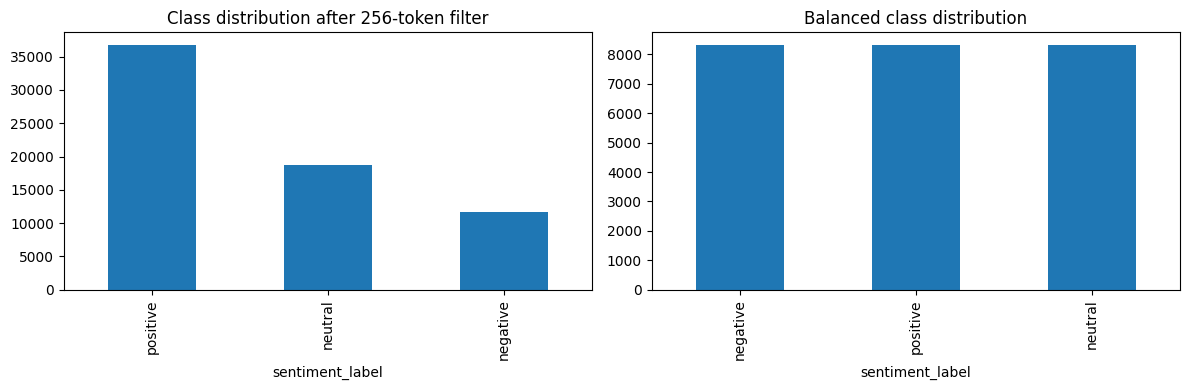

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_filtered["sentiment_label"].value_counts().plot(kind="bar", ax=axes[0], title="Class distribution after 256-token filter")
df_balanced["sentiment_label"].value_counts().plot(kind="bar", ax=axes[1], title="Balanced class distribution")

plt.tight_layout()
plt.show()


In [6]:
df_bert = df_balanced[["description", "sentiment_label"]] # For the Bert models we just need descriptions and their label


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


We encode the label in the following way: {"positive": 0, "negative": 1, "neutral": 2}, since it is coherent with FinBert labeling (that we will use later)

We split the dataset in the following way:
- 70% Training
- 15% Validation
- 15% Test

In [8]:
X = df_bert["description"]
y = df_bert["sentiment_label"].map({"positive": 0, "negative": 1, "neutral": 2}).astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=100)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=100)

print(X_train.shape, X_val.shape, X_test.shape)
y_train.head()


(17499,) (3750,) (3750,)


15970    1
14574    1
21395    0
2037     2
19629    1
Name: sentiment_label, dtype: int64

# Tokenizer
The tokenizer is the component responsible for converting raw text into the numerical format that the model expects as input. DistilBERT uses a WordPiece tokenizer, the same as BERT, which operates in several sequential steps.

The process begins with text normalization. Since DistilBERT uses the uncased variant, the text is lowercased and control characters are removed, while whitespace and punctuation are normalized.

WordPiece tokenization splits the text into subword units from a fixed vocabulary of about thirty thousand tokens. Instead of always splitting on whole words, it breaks rare or unknown words into smaller known pieces. For instance, "playing" might become ["play", "##ing"], where the ## prefix indicates a continuation token. If a word cannot be decomposed into known pieces at all, it is replaced by the special [UNK] token.

Once the text has been tokenized, special tokens are inserted. A [CLS] token is placed at the beginning of every sequence. A [SEP] token is appended at the end to mark the boundary of the sequence. 

Finally, each token is mapped to an integer ID from the model vocabulary, since the model operates entirely on numbers rather than strings.

## Parameters

- padding="max_length: pads all sequences to the same fixed length by appending some 0 at the end

- truncation=True: sequences longer than max_length are cut off at the limit.

- max_length=256: sets the fixed length for all sequences. This value directly affects VRAM usage and training speed

- return_tensors="pt": returns PyTorch tensors rather than Python lists. 

In [9]:
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_tokenized = tokenizer(
    X_train.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

val_tokenized = tokenizer(
    X_val.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

test_tokenized = tokenizer(
    X_test.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)


In [10]:
y_train_tensor = torch.tensor(y_train.values)
y_val_tensor = torch.tensor(y_val.values)
y_test_tensor = torch.tensor(y_test.values)

In [11]:
"""
A Dataset class is required so that the DataLoader can iterate through it in batches 
"""
class Dataset(torch.utils.data.Dataset):
  def __init__(self,tokens, labels):
    self.tokens = tokens
    self.labels = labels

  def __getitem__(self, idx):
      item = {key: val[idx] for key, val in self.tokens.items()}
      item["labels"] = self.labels[idx]
      return item

  def __len__(self):
      return len(self.labels)

The train_epoch and eval_epoch functions define a single pass through the training and validation sets respectively.

As input the model will take:
- input_ids: the IDs of the tokens in the model vocabulary (batch_size, max_length)
- attention mask: a binary tensor containing 1 for real tokens and 0 for padding tokens. Since all sequences are padded to the same length, the model needs to know which positions contain actual text and which are just padding. (batch_size, max_length)
- labels: tensor with ground truth classes

In [12]:
from tqdm import tqdm


def train_epoch(model ,dataloader, optimizer, scheduler, device):
  model.train()
  total_loss = 0

  for batch in tqdm(dataloader, desc = "Training"):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()

        # Forward pass: compute model predictions and loss
        # BertForSequenceClassification automatically computes loss when labels are provided
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss

        # Backward pass: compute gradients
    loss.backward()

        # Update weights based on gradients
    optimizer.step()

    scheduler.step()

    total_loss += loss.item()

  return total_loss / len(dataloader)

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
    return total_loss / len(dataloader)

## DistilBert Training

To avoid overfitting we modified the default parameters of DistilBert:
- Increased the Dropout to 0.3 (from 0.1)
- Increased the Attention Dropout to 0.15 (from 0.1). The attention dropout is a dropout applied inside the attention mechanism of the transformer
- Increased Weigth decay to 0.05 (from 0.1)

We also chose a really little learning rate (5e-6)

We also add the early stopping through the patience; if the validation loss does not change more than min_delta = 0.01 for two consecutive epoch (patience = 2), the training is stopped and the best weights are saved.

In [ ]:
batch_size = 32          
lr = 5e-6
warmup_ratio = 0.1

best_val_loss = float('inf')
train_losses = []
val_losses = []
train_loader = DataLoader(Dataset(train_tokenized, y_train_tensor), batch_size=batch_size)
val_loader = DataLoader(Dataset(val_tokenized, y_val_tensor), batch_size=batch_size)

config_finetune = DistilBertConfig.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
    output_attentions=True,
    dropout=0.3,
    attention_dropout=0.15
)
model_finetune = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", config=config_finetune)

model_finetune.to(device)

optimizer = AdamW(model_finetune.parameters(), lr=lr, weight_decay=0.05)
epochs = 5
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(warmup_ratio * total_steps),
    num_training_steps=total_steps)

patience = 2
min_delta = 0.01
patience_counter = 0
best_val_loss = float('inf')
best_epoch = -1
best_ckpt_path = os.path.join(checkpoint_dir_256, "bert_best_model_256token.pt")

for epoch in range(epochs):
    print(f"\n Epoch {epoch + 1}/{epochs}")
    train_loss = train_epoch(model_finetune, train_loader, optimizer, scheduler, device)
    val_loss = eval_epoch(model_finetune, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1} — Training loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")

    improved = val_loss < best_val_loss * (1 - min_delta)

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model_finetune.state_dict(), best_ckpt_path)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping triggered. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6684.15it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Epoch 1/5


Validation: 100%|██████████| 118/118 [00:15<00:00,  7.47it/s]


Epoch 1 — Training loss: 0.9867, Validation loss: 0.8484
New best model saved (val_loss=0.8484)

 Epoch 2/5


Validation: 100%|██████████| 118/118 [00:15<00:00,  7.39it/s]


...

Epoch 3 — Training loss: 0.7914, Validation loss: 0.8043
New best model saved (val_loss=0.8043)

 Epoch 4/5


Validation: 100%|██████████| 118/118 [00:17<00:00,  6.78it/s]


Epoch 4 — Training loss: 0.7657, Validation loss: 0.8036
No improvement. Patience: 1/2

 Epoch 5/5


Validation: 100%|██████████| 118/118 [00:16<00:00,  7.22it/s]

Epoch 5 — Training loss: 0.7549, Validation loss: 0.8032
No improvement. Patience: 2/2

 Early stopping triggered. Best epoch: 3, Best val loss: 0.8043

✅ Training complete. Best epoch: 3, Best val loss: 0.8043


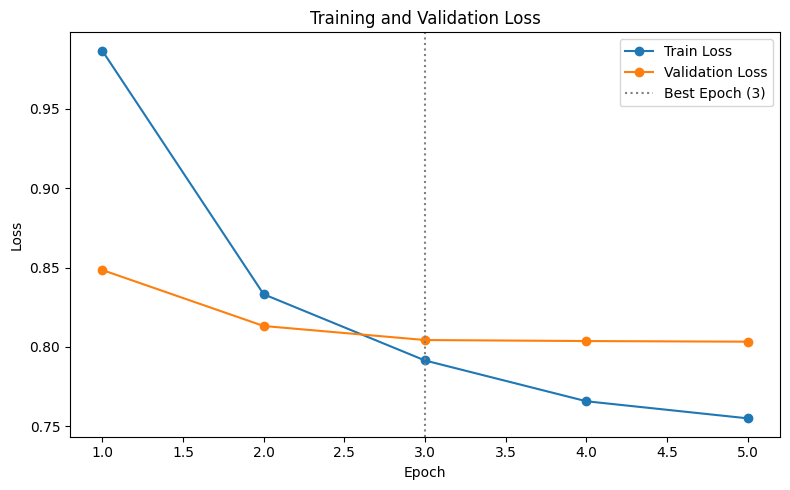

In [15]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch})')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

The graph above shows a plateau in the validation loss after the third epoch, so we saved the weights of this epoch

After loading the best weights we evaluate on the training set obtaining the following results:


 Classification Report:
              precision    recall  f1-score   support

    positive       0.65      0.59      0.62      1259
    negative       0.66      0.68      0.67      1241
     neutral       0.64      0.68      0.66      1250

    accuracy                           0.65      3750
   macro avg       0.65      0.65      0.65      3750
weighted avg       0.65      0.65      0.65      3750

Confusion Matrix:


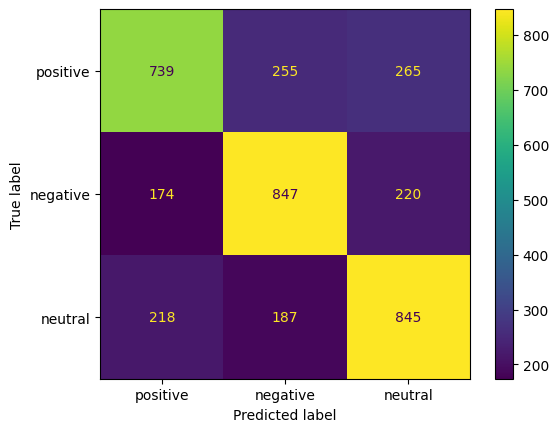

In [16]:
model_finetune.load_state_dict(torch.load(best_ckpt_path, map_location=device))
model_finetune.to(device)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_loader = DataLoader(Dataset(test_tokenized, y_test_tensor), batch_size=batch_size)

model_finetune.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model_finetune(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['positive', 'negative', 'neutral']
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()


The model achieves an overall accuracy of 0.65 (the accuracy is relevant since the classes are balanced) and a macro F1 of 0.65, with remarkably balanced performance across all three classes.

The negative class is the best predicted, with F1 of 0.67 and the highest recall (0.68), possibly due to the fact that negative financial news tends to contain more distinctive keywords (such as "losses", "bankruptcy", "decline") that the model can recognize easily.

The positive class has the lowest recall (0.59), meaning the model misses about 41% of positive examples, likely classifying them as neutral. This is something that often happen in financial sentiment analysis, positive news is often expressed in cautious words ("modest growth", "slightly above expectations") that is easily confused with neutral reporting.

The neutral class performs in between, with recall 0.68 but the lowest precision among the three (0.64), **meaning the model tends to over-predict neutral taht is coherent with the low recall for the positive class**.

Overall these results are consistent with what is expected for DistilBERT on financial news descriptions, and represent a clear improvement over the BiLSTM baseline (0.60 F1) achieved in this same project.

# FinBert

FinBert is a Bert based model that has been pre-trained on financial news in order to perform sentiment analysis.

Since we are also performing sentiment analysis on financial news, we decided to just perform **feature extraction** on FinBert, in particular all the 12 transformers layers are forzen and we are updating just the final classification head.

The max number of tokens for each document is still 256.

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

finbert_tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")

train_tokenized_fb = finbert_tokenizer(X_train.tolist(), padding="max_length", truncation=True, max_length=256, return_tensors="pt")
val_tokenized_fb   = finbert_tokenizer(X_val.tolist(),   padding="max_length", truncation=True, max_length=256, return_tensors="pt")
test_tokenized_fb  = finbert_tokenizer(X_test.tolist(),  padding="max_length", truncation=True, max_length=256, return_tensors="pt")


In [ ]:
finbert = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Freeze all weights
for param in finbert.parameters():
    param.requires_grad = False

# Train only Classification Head
for param in finbert.classifier.parameters():
    param.requires_grad = True

print(finbert.config.id2label)  

finbert.to(device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 27743.03it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'positive', 1: 'negative', 2: 'neutral'}


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## FinBert Training

Also here we use the patience for early stopping

In [ ]:
batch_size   = 32
lr           = 2e-4
warmup_ratio = 0.1

train_losses_fb = []
val_losses_fb   = []

train_loader_fb = DataLoader(Dataset(train_tokenized_fb, y_train_tensor), batch_size=batch_size)
val_loader_fb   = DataLoader(Dataset(val_tokenized_fb,   y_val_tensor),   batch_size=batch_size)

optimizer_fb = AdamW(filter(lambda p: p.requires_grad, finbert.parameters()), lr=lr, weight_decay=0.01)
epochs       = 5
total_steps  = len(train_loader_fb) * epochs
scheduler_fb = get_linear_schedule_with_warmup(optimizer_fb, num_warmup_steps=int(warmup_ratio * total_steps), num_training_steps=total_steps)

patience         = 2
min_delta        = 0.01
patience_counter = 0
best_val_loss_fb = float('inf')
best_epoch_fb    = -1
best_ckpt_fb = os.path.join(checkpoint_dir_256, "finbert_best_model_256token.pt")

for epoch in range(epochs):
    print(f"\n Epoch {epoch + 1}/{epochs}")
    train_loss = train_epoch(finbert, train_loader_fb, optimizer_fb, scheduler_fb, device)
    val_loss   = eval_epoch(finbert, val_loader_fb, device)
    train_losses_fb.append(train_loss)
    val_losses_fb.append(val_loss)
    print(f"Epoch {epoch+1} — Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

    if val_loss < best_val_loss_fb * (1 - min_delta):
        best_val_loss_fb = val_loss
        best_epoch_fb    = epoch + 1
        patience_counter = 0
        torch.save(finbert.state_dict(), best_ckpt_fb)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping. Best epoch: {best_epoch_fb}, Best val loss: {best_val_loss_fb:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch_fb}, Best val loss: {best_val_loss_fb:.4f}")



 Epoch 1/5


Validation: 100%|██████████| 118/118 [00:27<00:00,  4.34it/s]


Epoch 1 — Train loss: 0.9718, Val loss: 0.9117
New best model saved (val_loss=0.9117)

 Epoch 2/5


Validation: 100%|██████████| 118/118 [00:27<00:00,  4.32it/s]


Epoch 2 — Train loss: 0.9057, Val loss: 0.8989
New best model saved (val_loss=0.8989)

 Epoch 3/5


Validation: 100%|██████████| 118/118 [00:27<00:00,  4.24it/s]


Epoch 3 — Train loss: 0.9019, Val loss: 0.8933
No improvement. Patience: 1/2

 Epoch 4/5


Validation: 100%|██████████| 118/118 [00:27<00:00,  4.25it/s]

Epoch 4 — Train loss: 0.8966, Val loss: 0.8922
No improvement. Patience: 2/2

 Early stopping. Best epoch: 2, Best val loss: 0.8989

✅ Training complete. Best epoch: 2, Best val loss: 0.8989


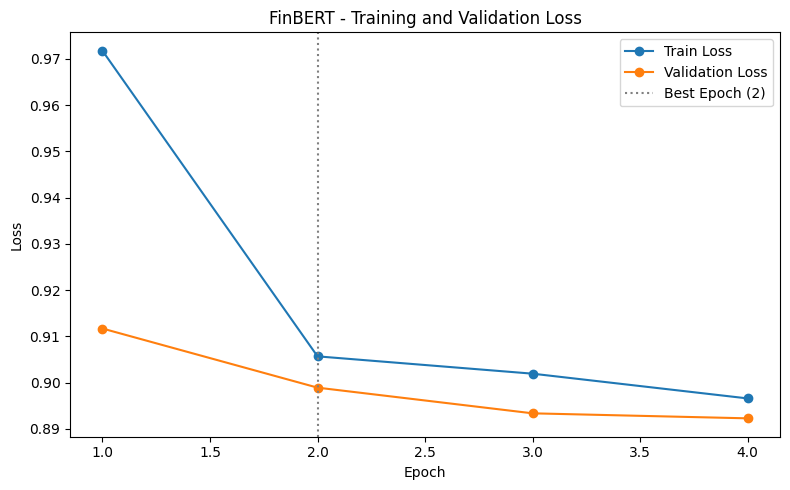

In [16]:
epochs_range = range(1, len(train_losses_fb) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses_fb, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses_fb,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch_fb, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch_fb})')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('FinBERT - Training and Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()

From the graph above we can see that there is a plateau after the second epoch, so we saved the weights of this epoch.

Loading the best weights we obtain the following results:


 Classification Report — FinBERT:
              precision    recall  f1-score   support

    positive       0.62      0.48      0.54      1259
    negative       0.63      0.60      0.62      1241
     neutral       0.52      0.66      0.59      1250

    accuracy                           0.58      3750
   macro avg       0.59      0.58      0.58      3750
weighted avg       0.59      0.58      0.58      3750

Confusion Matrix:


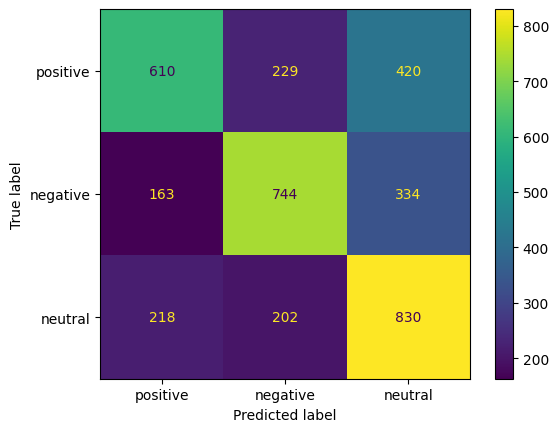

In [17]:
finbert.load_state_dict(torch.load(best_ckpt_fb, map_location=device))
finbert.to(device)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_loader_fb = DataLoader(Dataset(test_tokenized_fb, y_test_tensor), batch_size=batch_size)

finbert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader_fb:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = finbert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['positive', 'negative', 'neutral']
print("\n Classification Report — FinBERT:")
print(classification_report(all_labels, all_preds, target_names=label_names))
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()


We obtain an average accuracy of 0.59 and an average F1 score of 0.58.

As for the results of DistilBert the low recall for the positive class (0.48) is coherent with the low precision of the neutral class (0.52)

The FinBert performance is similar to the one obtained from the BiLSTM, and worse than DistilBert. This is due to the fact that we are performing feature extraction (updating only the final Classification Head) and not fine-tuning.

# BERT Base

Bert Base has double the size of DistilBert (12 transformers layers) and differently from FinBert, it has been trained with data from a variety of domains.

Since our data is from a specific domain we decided to perform **fine-tuning** updating all the layers

In [13]:
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_tokenized_bert = bert_tokenizer(X_train.tolist(), padding="max_length", truncation=True, max_length=256, return_tensors="pt")
val_tokenized_bert   = bert_tokenizer(X_val.tolist(),   padding="max_length", truncation=True, max_length=256, return_tensors="pt")
test_tokenized_bert  = bert_tokenizer(X_test.tolist(),  padding="max_length", truncation=True, max_length=256, return_tensors="pt")


To avoid overfitting we modified the default parameters of Bert:
- Increased the Dropout to 0.2 (from 0.1)
- Increased the Attention Dropout to 0.15 (from 0.1). The attention dropout is a dropout applied inside the attention mechanism of the transformer

We also chose a little learning rate (2e-5) since we are fine-tuning

We also add the early stopping through the patience; if the validation loss does not change more than min_delta = 0.01 for two consecutive epoch (patience = 2), the training is stopped and the best weights are saved.

In [ ]:
config_bert = BertConfig.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    output_attentions=True,
    hidden_dropout_prob=0.2, 
    attention_probs_dropout_prob=0.15 
)
model_bert = BertForSequenceClassification.from_pretrained("bert-base-uncased", config=config_bert)
model_bert.to(device)
print("BERT base loaded")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9127.72it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

BERT base loaded


## Bert Base Training

In [ ]:
batch_size_bert = 32
lr_bert         = 2e-5 
warmup_ratio    = 0.1

train_losses_bert = []
val_losses_bert   = []

train_loader_bert = DataLoader(Dataset(train_tokenized_bert, y_train_tensor), batch_size=batch_size_bert)
val_loader_bert   = DataLoader(Dataset(val_tokenized_bert,   y_val_tensor),   batch_size=batch_size_bert)

optimizer_bert = AdamW(model_bert.parameters(), lr=lr_bert, weight_decay=0.01) 
epochs_bert    = 3
total_steps    = len(train_loader_bert) * epochs_bert
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(warmup_ratio * total_steps),
    num_training_steps=total_steps
)

patience         = 2
min_delta        = 0.01
patience_counter = 0
best_val_loss_bert = float('inf')
best_epoch_bert    = -1
best_ckpt_bert = os.path.join(checkpoint_dir_256, "bert_base_best_model_256token.pt")

for epoch in range(epochs_bert):
    print(f"\n Epoch {epoch + 1}/{epochs_bert}")
    train_loss = train_epoch(model_bert, train_loader_bert, optimizer_bert, scheduler_bert, device)
    val_loss   = eval_epoch(model_bert, val_loader_bert, device)
    train_losses_bert.append(train_loss)
    val_losses_bert.append(val_loss)
    print(f"Epoch {epoch+1} — Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

    if val_loss < best_val_loss_bert * (1 - min_delta):
        best_val_loss_bert = val_loss
        best_epoch_bert    = epoch + 1
        patience_counter   = 0
        torch.save(model_bert.state_dict(), best_ckpt_bert)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping. Best epoch: {best_epoch_bert}, Best val loss: {best_val_loss_bert:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch_bert}, Best val loss: {best_val_loss_bert:.4f}")



 Epoch 1/3


Validation: 100%|██████████| 118/118 [00:39<00:00,  3.02it/s]


Epoch 1 — Train loss: 0.9190, Val loss: 0.7937
New best model saved (val_loss=0.7937)

 Epoch 2/3


Validation: 100%|██████████| 118/118 [00:39<00:00,  3.02it/s]


Epoch 2 — Train loss: 0.7463, Val loss: 0.7721
New best model saved (val_loss=0.7721)

 Epoch 3/3


Validation: 100%|██████████| 118/118 [00:39<00:00,  3.00it/s]

Epoch 3 — Train loss: 0.6547, Val loss: 0.7953
No improvement. Patience: 1/2

✅ Training complete. Best epoch: 2, Best val loss: 0.7721


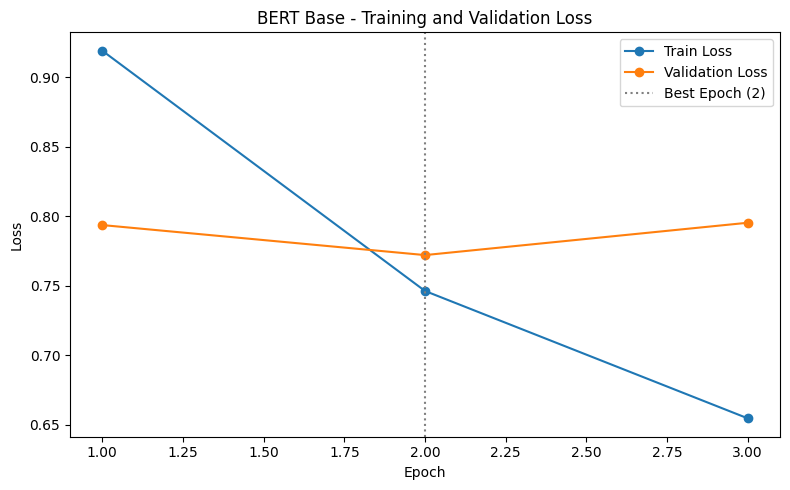

In [16]:
epochs_range = range(1, len(train_losses_bert) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses_bert, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses_bert,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch_bert, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch_bert})')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('BERT Base - Training and Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()


From the graph above we can notice a plateau after the second epoch, so we save the weights of this epoch.

After the loading the best weights we obtain the following results 


 Classification Report — BERT Base:
              precision    recall  f1-score   support

    positive       0.71      0.58      0.64      1259
    negative       0.70      0.67      0.68      1241
     neutral       0.63      0.77      0.69      1250

    accuracy                           0.67      3750
   macro avg       0.68      0.67      0.67      3750
weighted avg       0.68      0.67      0.67      3750

Confusion Matrix:


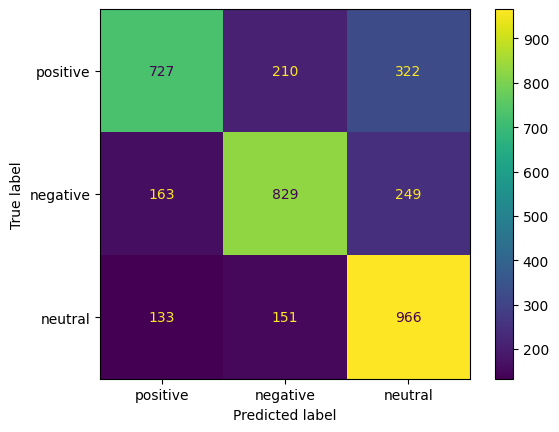

In [17]:
model_bert.load_state_dict(torch.load(best_ckpt_bert, map_location=device))
model_bert.to(device)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_loader_bert = DataLoader(Dataset(test_tokenized_bert, y_test_tensor), batch_size=batch_size_bert)

model_bert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader_bert:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['positive', 'negative', 'neutral']
print("\n Classification Report — BERT Base:")
print(classification_report(all_labels, all_preds, target_names=label_names))
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()


We obtain an average accuracy of 0.68 and an average F1 score of 0.67.

As for the results of DistilBert the low recall for the positive class (0.58) is coherent with the low precision of the neutral class (0.63)

The Bert Base performance is similar to the one obtained from the DistilBert, and better than FinBert and BiLSTM. Even though the number of Bert weights are about double the DistilBert weights, the performance is similar